## Figure 1: Dataset Harmonization

### Import figure functions
Each figure file is configured to create a component of figure 1 and return it as a standalone matplotlib figure.

In [20]:
%load_ext rpy2.ipython
from figure1a import make_figure as make_figure_1a
from figure1b import make_figure as make_figure_1b
from figure1c import make_figure as make_figure_1c

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


### Subfigure 1a: Batch harmonization PCA
The below plots PCA scores, alongside confidence ellipses, to compare datasets across the BeatAML 210, Pilot study, and Bridging sample cohorts. Bridging samples consist of those collected as part of the original BeatAML 210 cohort that were later re-processed with the Pilot study samples to account for technical variation and help with harmonization between cohorts. The lower row of plots depicts the same PCA scores and confidence ellipses but colors samples based on patient race.


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.11.0) is available. Your version (4.10.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.11.0 release notes

https://python-docs.synapse.org/news/


Welcome, JLChin!

[syn69692583:combinedBeatAML_pilotMetadata.csv]: Found existing file at /Users/jackson.chin/.synapseCache/59/164972059/combinedBeatAML_pilotMetadata.csv, skipping download.
[syn71896311:rp_normalized_combat_edata_metab.csv]: Found existing file at /Users/jackson.chin/.synapseCache/125/166162125/rp_normalized_combat_edata_metab.csv, skipping download.
[syn25796769:PNNL_clinical_summary_03_03_2021.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/799/76897799/PNNL_clinical_summary_03_03_2021.xlsx, skipping download.
[syn68835814:PTRC_Exp26 Sample Key.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/432/161070432/PTRC_Exp26 Sample Key.xlsx, skipping download.
[syn71896667:normali

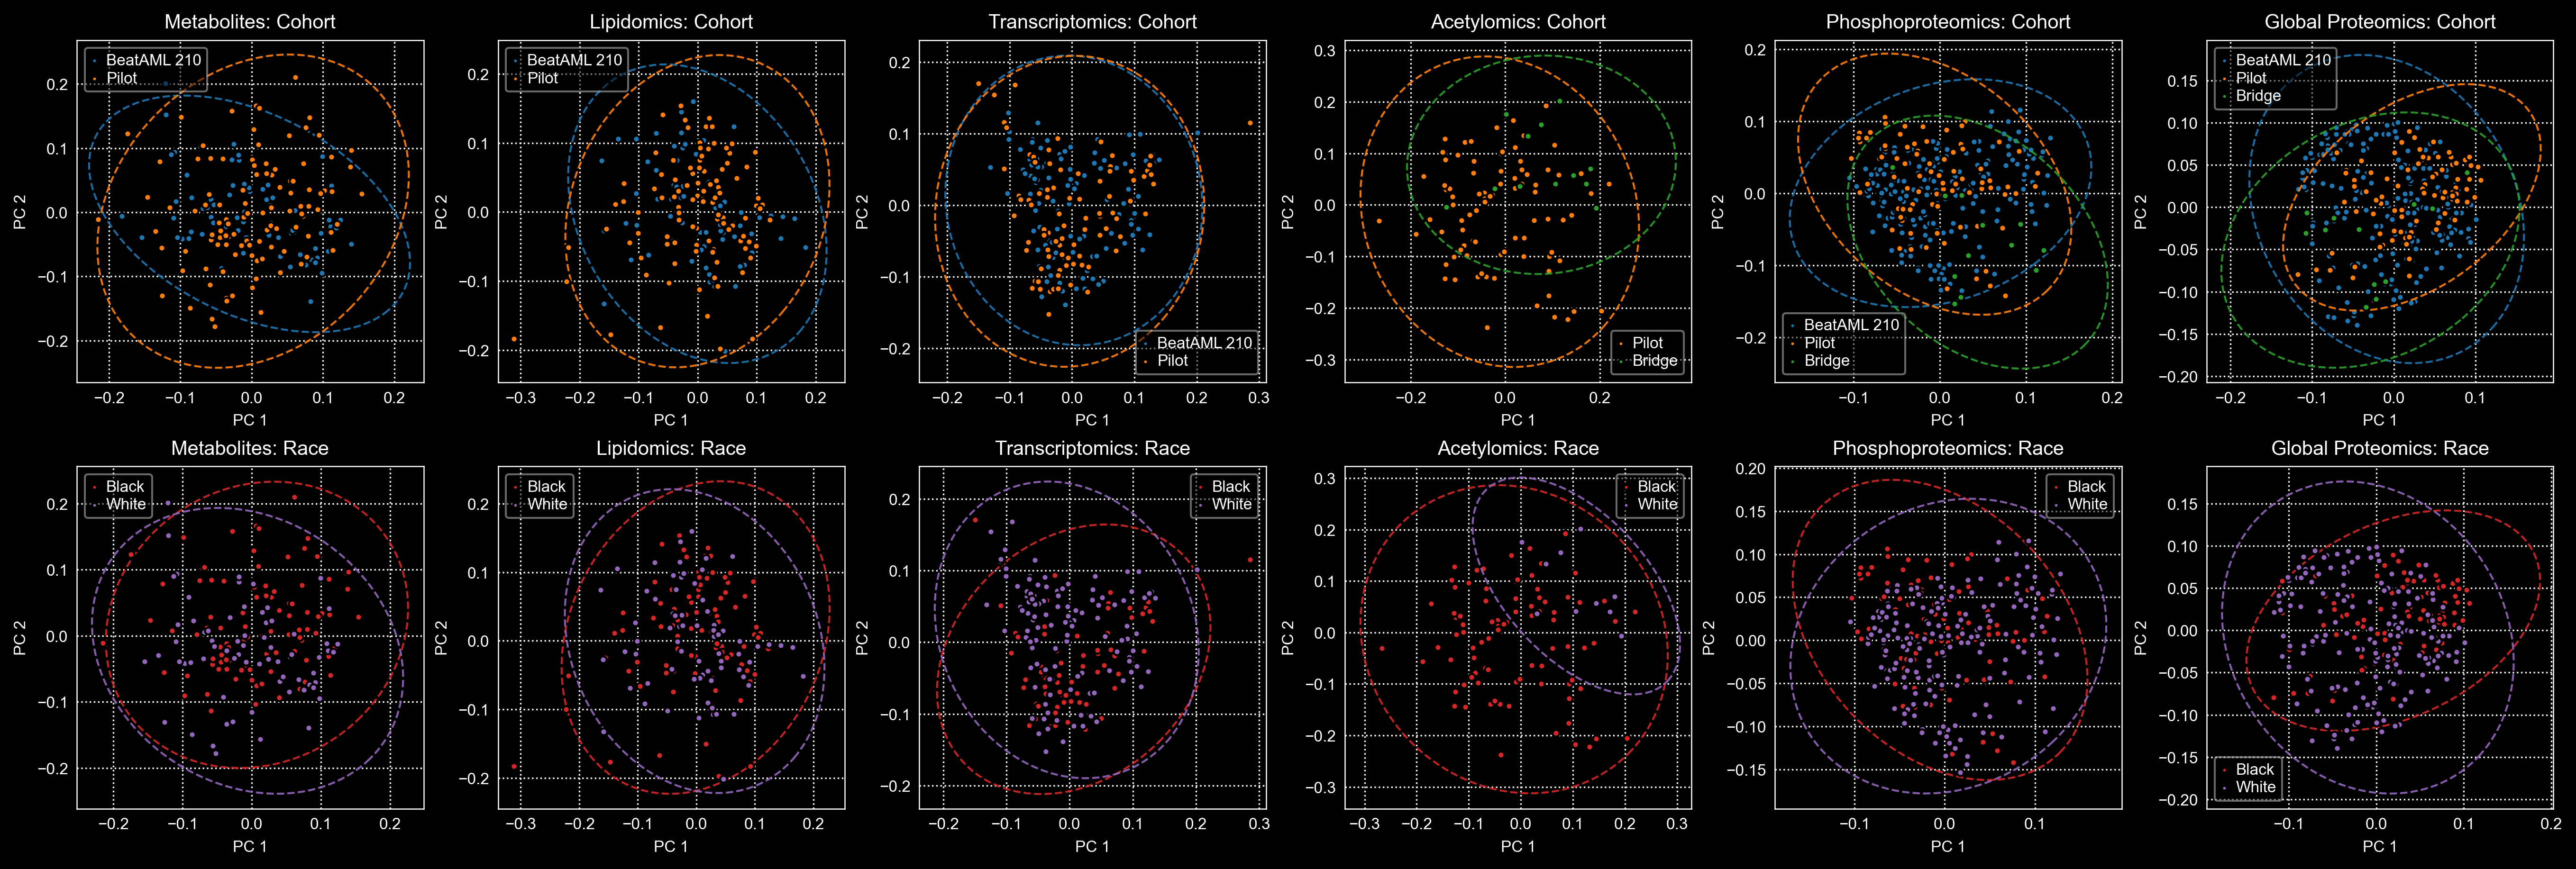

In [21]:
fig_1a = make_figure_1a()

### Subfigure 1b: Volcano Plots
With the datasets seeming harmonized, we can now compare across Black and White patients to see if there's any high-level differences in expression observable via conventional independent t-test. The below volcano plots compare log-fold change in each measurement between Black and White patients, and highlight those with (1) an adjusted p-value < 0.01 and (2) a base-2 log-fold change greater than 1.


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.11.0) is available. Your version (4.10.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.11.0 release notes

https://python-docs.synapse.org/news/


Welcome, JLChin!

[syn69692583:combinedBeatAML_pilotMetadata.csv]: Found existing file at /Users/jackson.chin/.synapseCache/59/164972059/combinedBeatAML_pilotMetadata.csv, skipping download.
[syn71896311:rp_normalized_combat_edata_metab.csv]: Found existing file at /Users/jackson.chin/.synapseCache/125/166162125/rp_normalized_combat_edata_metab.csv, skipping download.
[syn25796769:PNNL_clinical_summary_03_03_2021.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/799/76897799/PNNL_clinical_summary_03_03_2021.xlsx, skipping download.
[syn68835814:PTRC_Exp26 Sample Key.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/432/161070432/PTRC_Exp26 Sample Key.xlsx, skipping download.
[syn71896667:normali

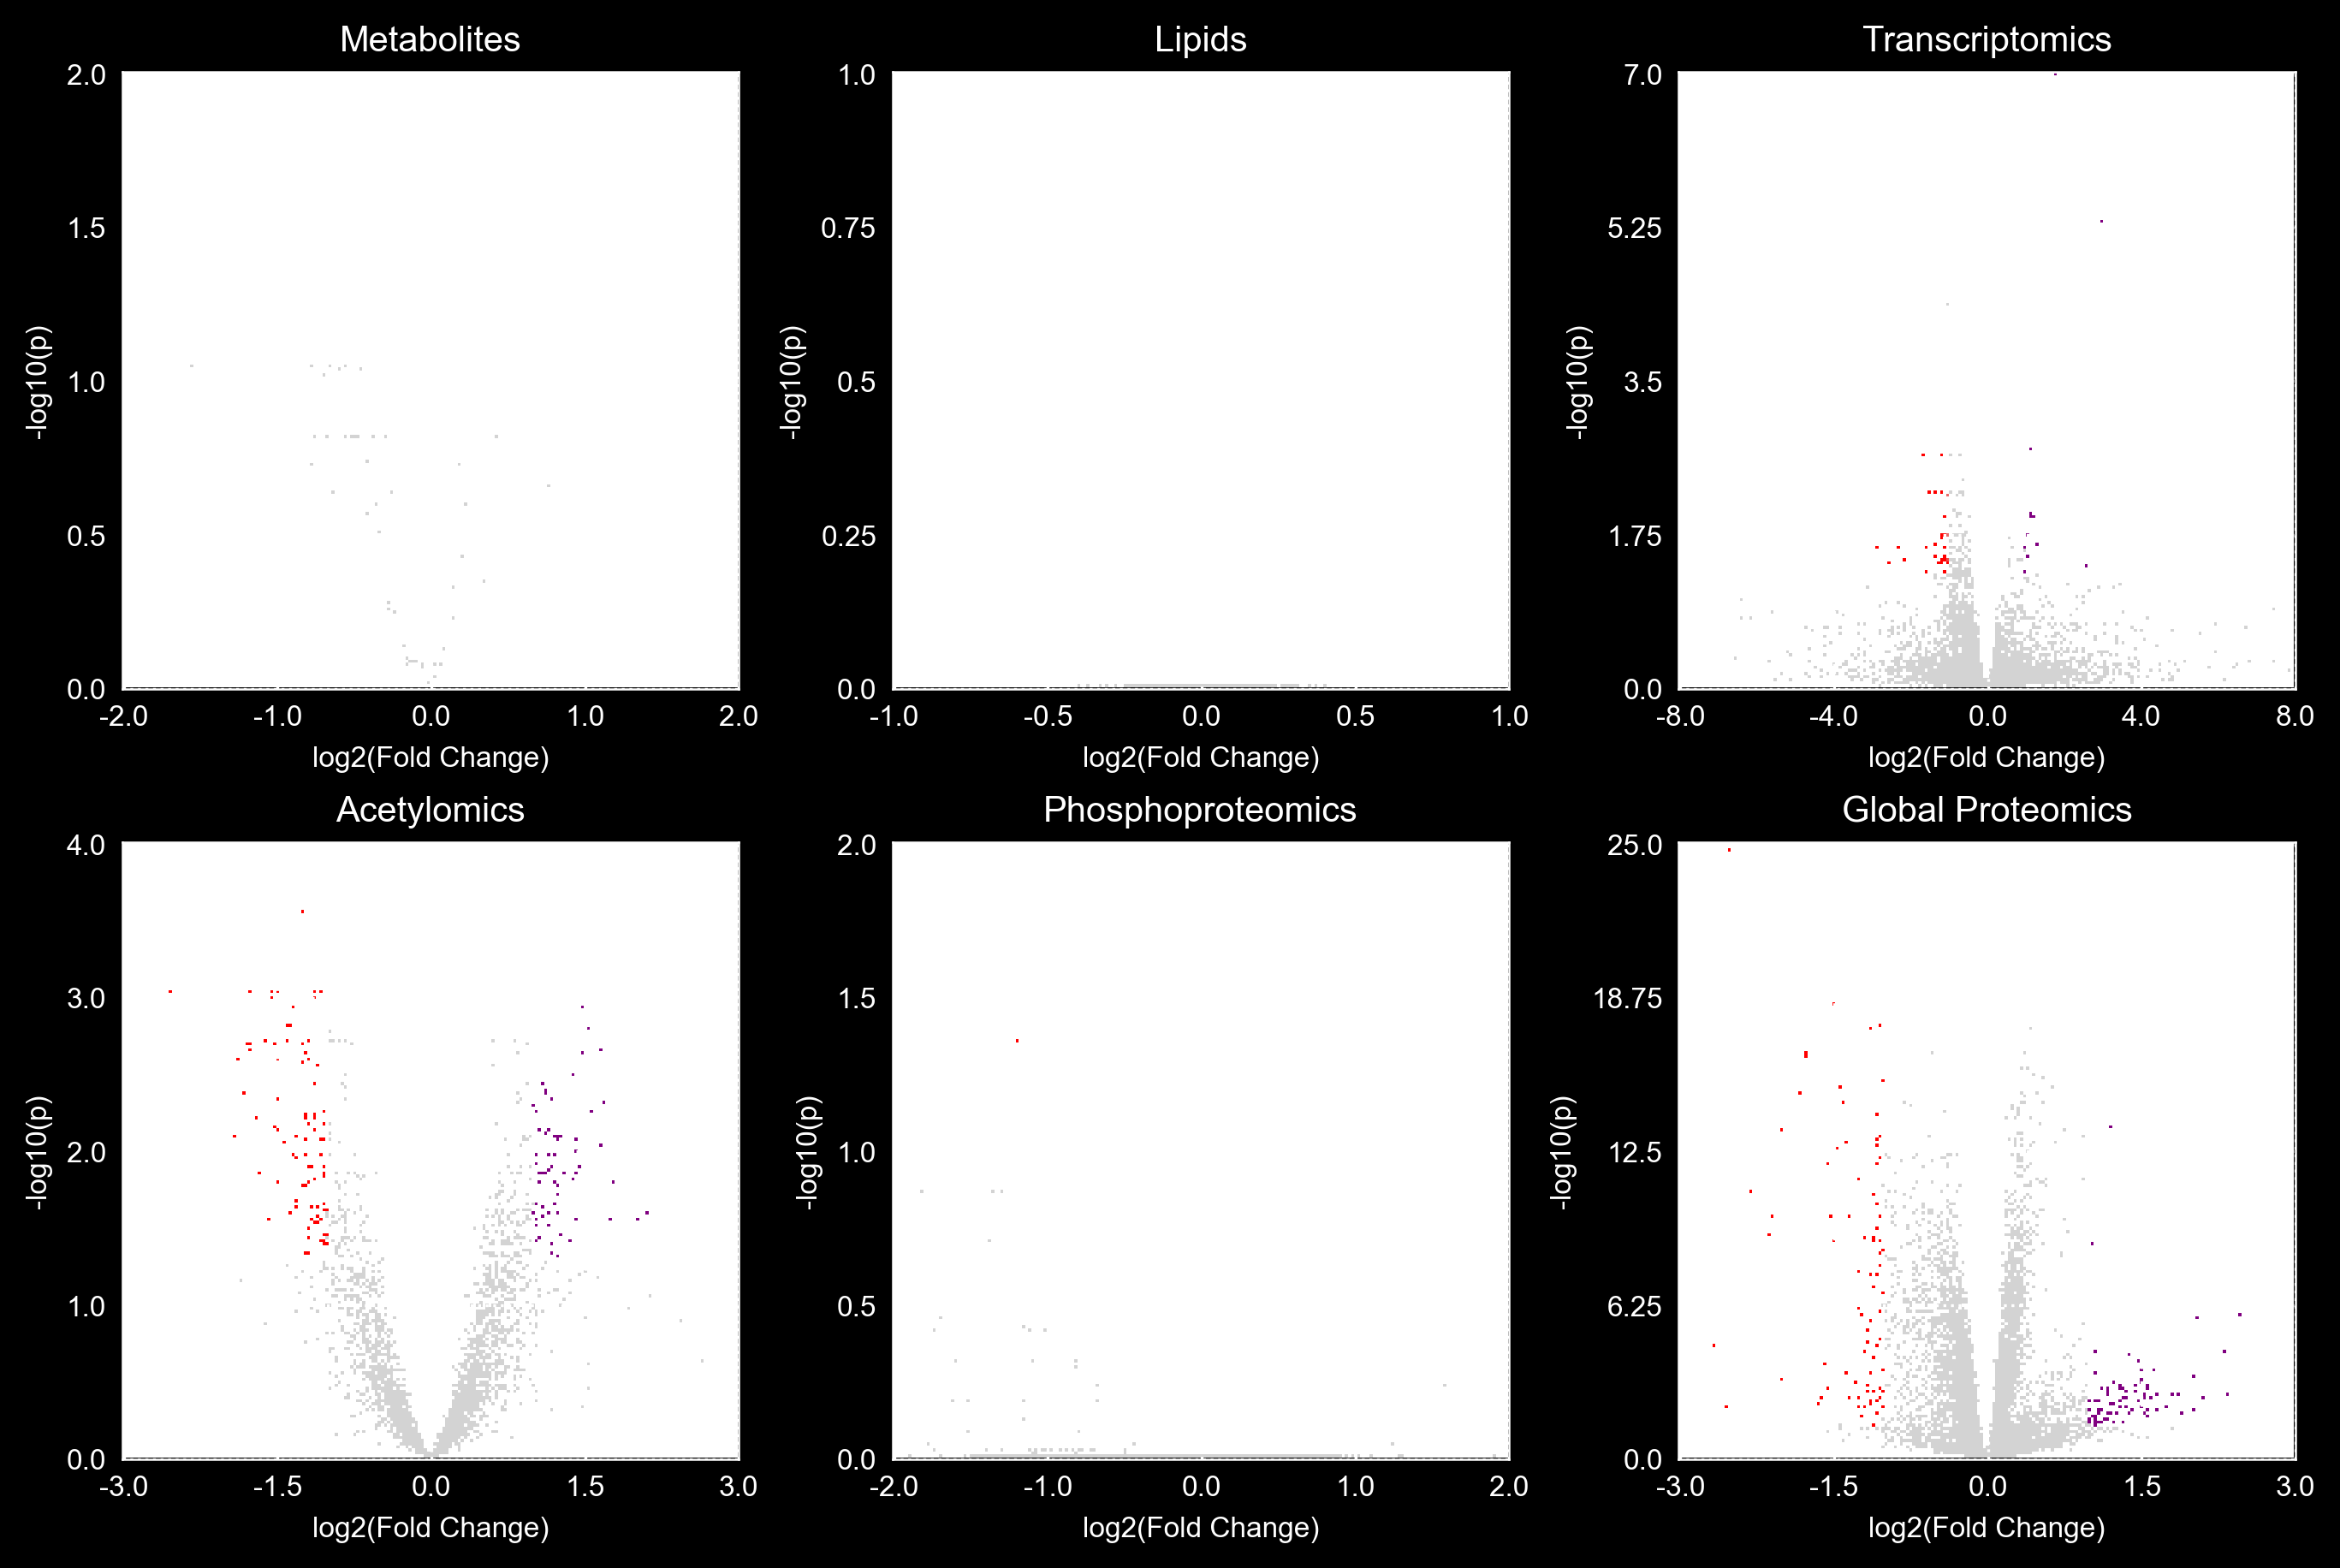

In [22]:
fig_1b = make_figure_1b()

### Subfigure 1c: Cell type composition
Finally, we can compare Black and White patients to see if there's large changes in AML cell types, as evidenced by global proteomics. This figure recreates the approach in [Bottomly et al](https://www.sciencedirect.com/science/article/pii/S1535610822003129?via%3Dihub#sec4) to estimate AML cell type compositions from global proteomic measurements. Without further subsetting of patients, these results indicate that Black and White patients exhibit similar cell type compositions.


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.11.0) is available. Your version (4.10.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.11.0 release notes

https://python-docs.synapse.org/news/


Welcome, JLChin!

[syn64126462:beataml_waves1to4_counts_dbgap.txt]: Found existing file at /Users/jackson.chin/.synapseCache/867/150013867/beataml_waves1to4_counts_dbgap.txt, skipping download.
[syn68820229:RNAseq expression data.txt]: Found existing file at /Users/jackson.chin/.synapseCache/317/160991317/RNAseq expression data.txt, skipping download.
[syn68820228:PilotYR_1_2_metadata_083024_withRNA DN.csv]: Found existing file at /Users/jackson.chin/.synapseCache/316/160991316/PilotYR_1_2_metadata_083024_withRNA DN.csv, skipping download.
[syn64126463:beataml_waves1to4_sample_mapping.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/872/150013872/beataml_waves1to4_sample_mapping.xlsx, skipping download.
[syn

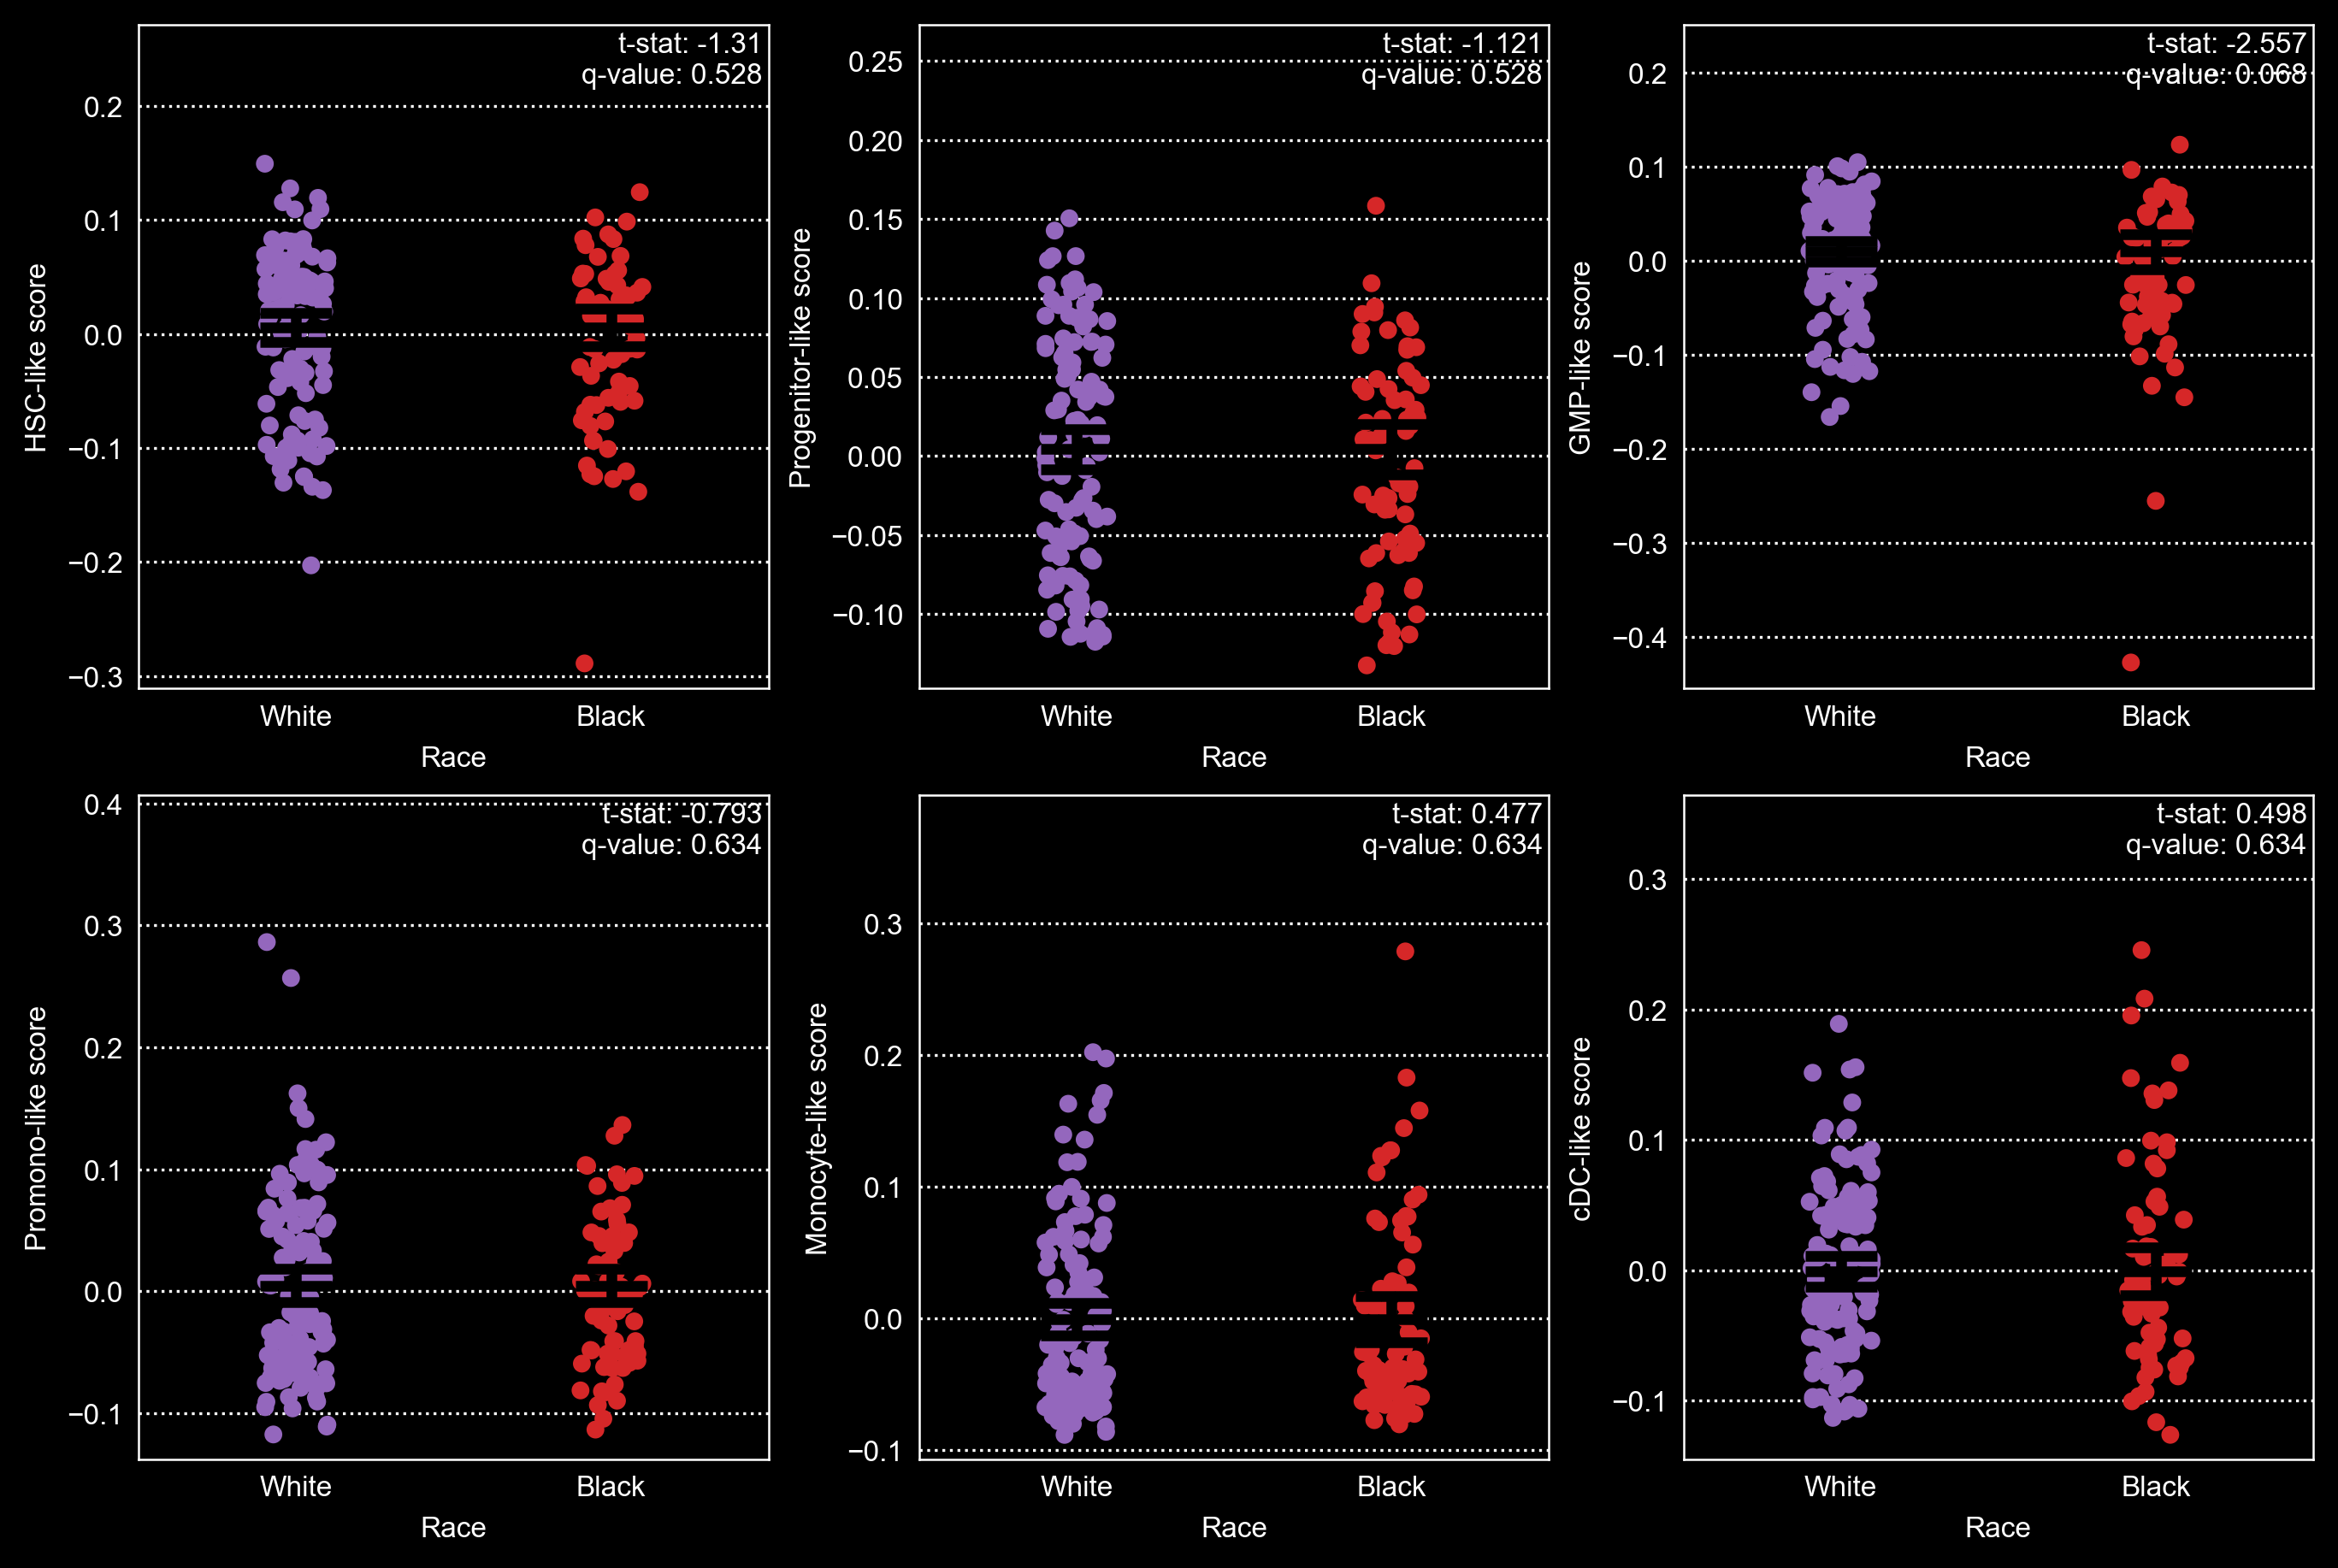

In [23]:
fig_1c = make_figure_1c()

### R Setup
Some 'omics--namely, the transcriptomics, phosphoproteomics, and global proteomics--require additional statistical power to capture race-based differences. This involves tools like *LIMMA* and *DESeq2* that are native to R; the blocks below port Python variables to R for analysis.

In [24]:
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from pilot.data_import import import_global, import_meta, import_phospho, import_rna

In [25]:
meta = import_meta()

global_prot = import_global(pre_corrected=True)
global_prot = pd.concat(global_prot, axis=0)
phospho = import_phospho(pre_corrected=True)
phospho = pd.concat(phospho, axis=0)

rna = import_rna(return_symbols=True, batch_correct=True, tpm=False)
rna = pd.concat(rna, axis=0)
rna = rna.loc[rna.index.intersection(meta.index), :]

with localconverter(ro.default_converter + pandas2ri.converter):
    global_r = ro.conversion.py2rpy(global_prot)
    phospho_r = ro.conversion.py2rpy(phospho)
    rna_r = ro.conversion.py2rpy(rna)
    meta_r = ro.conversion.py2rpy(meta)


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.11.0) is available. Your version (4.10.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.11.0 release notes

https://python-docs.synapse.org/news/


Welcome, JLChin!

[syn69692583:combinedBeatAML_pilotMetadata.csv]: Found existing file at /Users/jackson.chin/.synapseCache/59/164972059/combinedBeatAML_pilotMetadata.csv, skipping download.

UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.11.0) is available. Your version (4.10.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.11.0 release notes

https://python-docs.synapse.org/news/


Welcome, JLChin!

[syn25714248:ptrc_ex10_crosstab_global_gene_corrected.txt]: Found existing file at /Users/jackson.chin/.synapseCache/136/76083136/ptrc_ex10_crosstab_global_gene_corrected.txt, skipping download.
[syn69075555:ptrc_ex26_crosstab_global_corrected.txt]: Found

### Subfigure 1d: LIMMA Correlations
Phosphoproteomic and global measurements seem to show limited separation, possibly due to confoundment between race and batch variables--batch correction techniques can clear some batch effects, but it's plausible these approaches also toss meaningful race-based biological variation. Here, we can instead use LIMMA as a way to add statistical power and account for potential effects of batch in identifying race-based differences.

In addition: Warning message:
Partial NA coefficients for 1767 probe(s) 


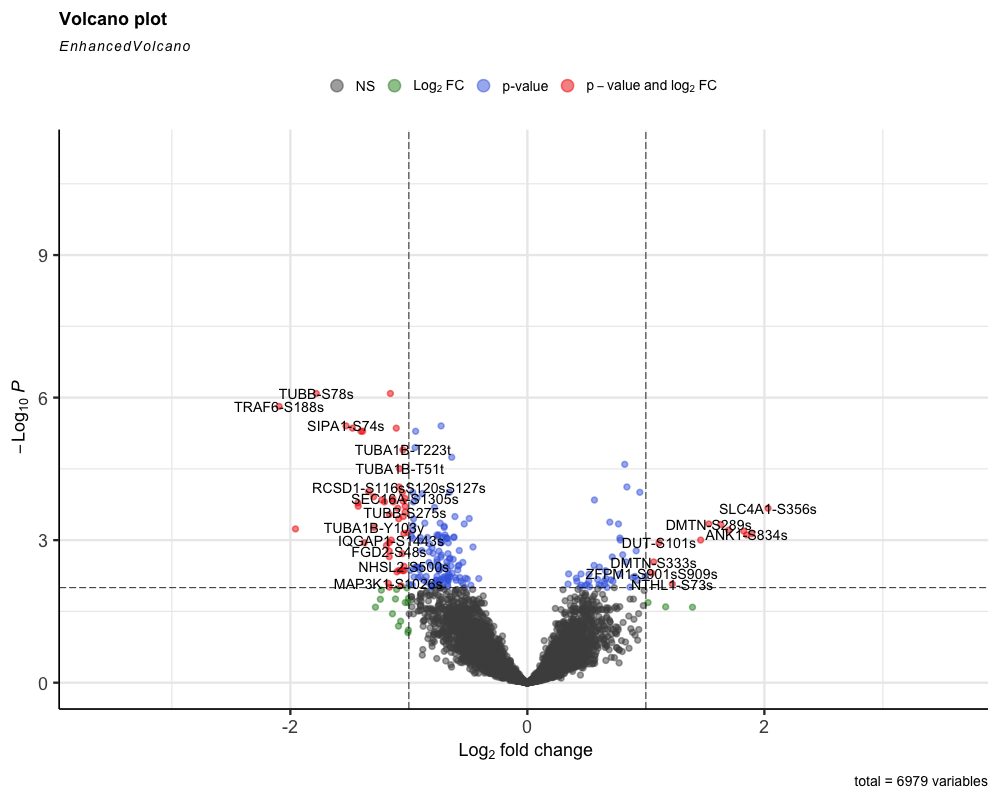

In [26]:
%%R -i phospho_r -i meta_r -w 1000 -h 800 -u px
source("../../src/r/proteomics/limma_correlations.R")
results <- run_limma(phospho_r, meta_r)
results$volcano

In addition: Warning message:
Partial NA coefficients for 2116 probe(s) 


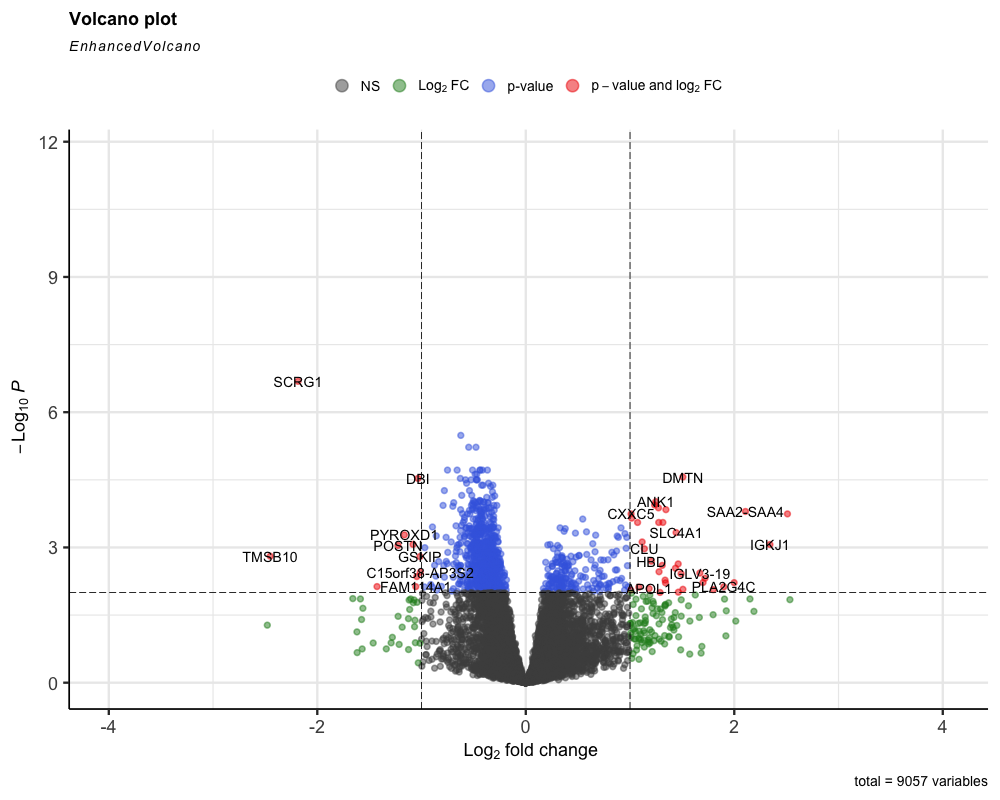

In [28]:
%%R -i global_r -i meta_r -w 1000 -h 800 -u px
source("../../src/r/proteomics/limma_correlations.R")
global_results <- run_limma(global_r, meta_r)
global_results$volcano

### Subfigure 1e: DESeq2 Analysis
Finally, to optimize comparisons for transcriptomic measurements, we'll use DESeq2--specifically designed for transcriptomic analysis--to compare RNA expression between black and white patients.

converting counts to integer mode
estimating size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
-- replacing outliers and refitting for 1015 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)
estimating dispersions
fitting model and testing
using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895
In addition: Warning message:
In DESeqDataSet(se, design = design, ignoreRank) :
  some variables in design formula are characters, converting to factors


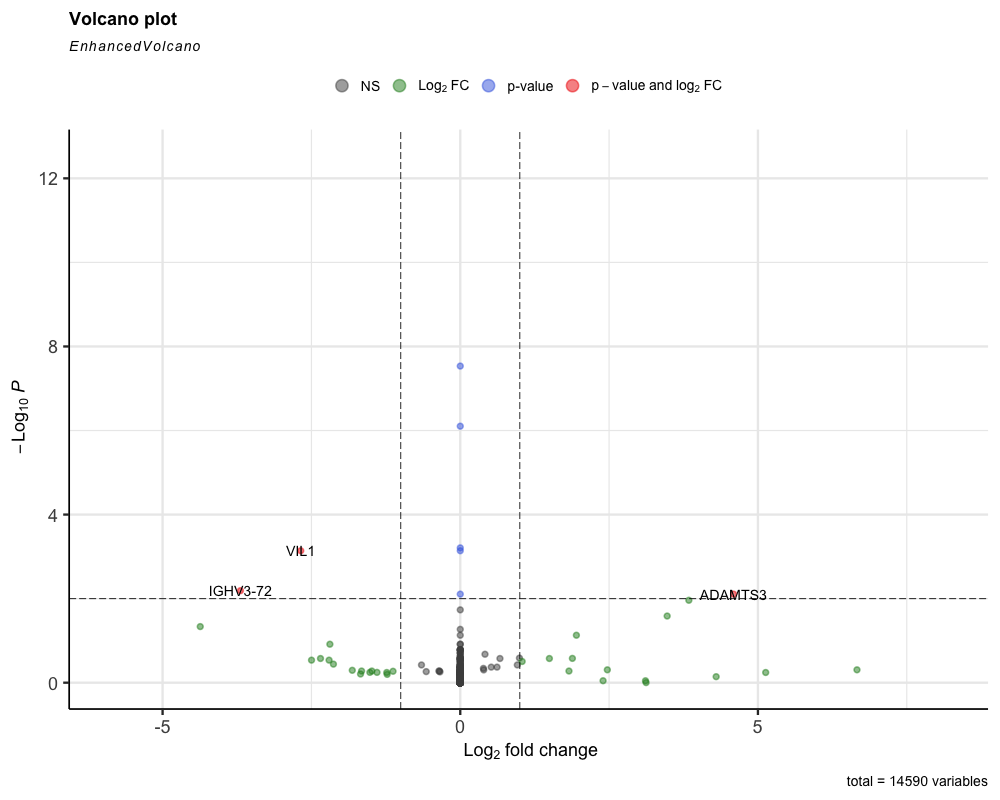

In [29]:
%%R -i rna_r -i meta_r -w 1000 -h 800 -u px
source("../../src/r/rna/differential_expression.R")
rna_results <- run_deseq2(rna_r, meta_r)
rna_results$volcano